# Очистка чертежа: классификация штрихов и поиск наконечников

**Пайплайн**

| шаг | что делает | результат |
|---|---|---|
| 1–2 | загрузка, масштаб, бинаризация | `binary`, `fg` |
| 3 | толщина штриха через distance transform | `thickness_map`, `t_axis` |
| 4 | классы толщины, KMeans по гистограмме оси | `cls_img` |
| 5 | класс **ребра** графа скелета по большинству голосов | `cls_vote` |
| 6 | удаление тонких линий с восстановлением по вписанным кругам | `mask_thick` |
| 7 | наконечники как пики ширины, h-maxima | семена наконечников |

**Две идеи, на которых всё держится**

1. *Решение принимается на ребре, а не на пикселе.* Попиксельная толщина врёт в узлах
   пересечений и на пологих дугах — там в штрих вписывается круг большего радиуса. Голосование
   по ребру графа снимает этот артефакт полностью.
2. *Наконечник — не объект, а пик ширины.* Он слит с контуром, поэтому не выделяется ни связной
   компонентой, ни формой, ни длиной. Зато ширина штриха вдоль чертежа кусочно-постоянна, и
   наконечник — единственное место, где она вырастает и падает обратно. Различающая величина —
   выпуклость пика над окружением, а её и находит `h_maxima`.

## 1. Загрузка и масштаб

In [124]:
from pathlib import Path

import cv2
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt

PALETTE = [(70, 130, 255), (60, 200, 90), (255, 190, 40), (255, 70, 70), (200, 80, 255), (0, 220, 220)]

In [125]:
folder = Path("/mnt/data/datasets/Сравнение чертежей/Эскизы датасет")
files = sorted(folder.glob("*.jpg"))

for i, f in enumerate(files):
    print(f"[{i}] {f.stem}")

[0] 1
[1] 10
[2] 11
[3] 12
[4] 13
[5] 14
[6] 15
[7] 16
[8] 17
[9] 18
[10] 19
[11] 2
[12] 20
[13] 21
[14] 3
[15] 4
[16] 5
[17] 6
[18] 7
[19] 8
[20] 9


In [126]:
IDX = 10

файл: 19.jpg
native: 1158x622 -> 6299x3383 (scale 5.440)
px_per_mm: 31.50 | эффективный dpi: 800


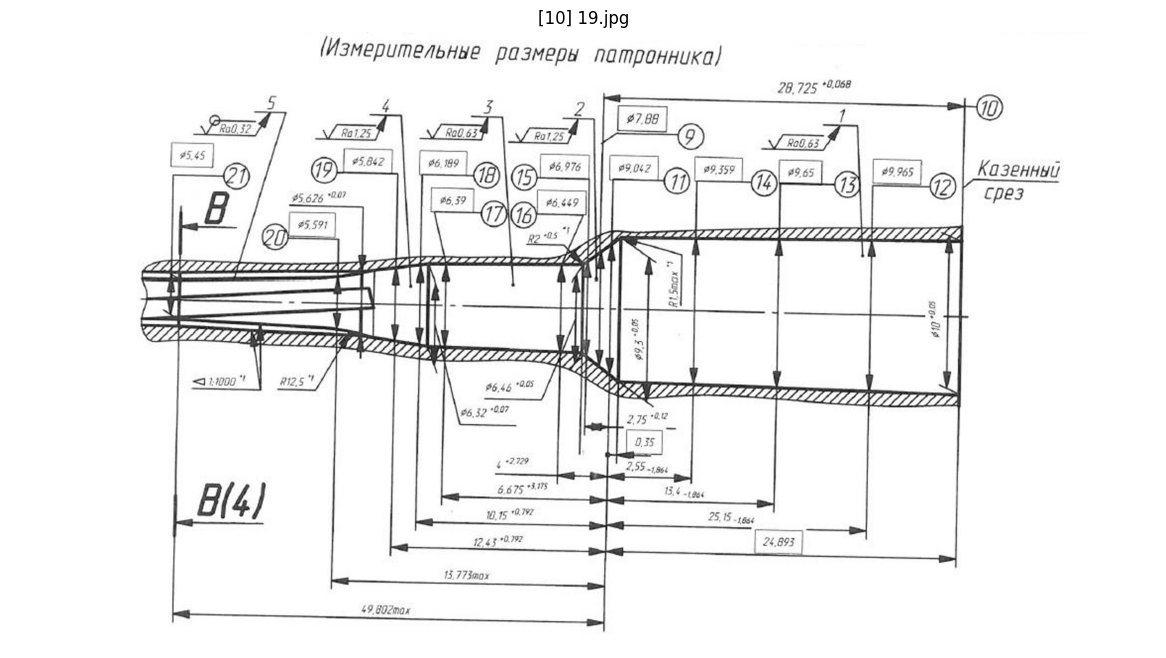

In [127]:
INCH_2_MM = 25.4
LONG_SIDE_MM, DPI = 200, 800


def rescale_image(image, long_side_mm, dpi):
    """Нормализует изображение так, чтобы длинная сторона отвечала заданному размеру в мм."""
    h, w = image.shape[:2]
    target_long_px = round(long_side_mm * dpi / INCH_2_MM)
    scale = target_long_px / max(h, w)
    interp = cv2.INTER_CUBIC if scale > 1 else cv2.INTER_AREA
    return cv2.resize(image, (round(w * scale), round(h * scale)), interpolation=interp), scale


img_native = cv2.imread(str(files[IDX]), cv2.IMREAD_COLOR)
img_bgr, scale = rescale_image(img_native, LONG_SIDE_MM, DPI)
px_per_mm = max(img_bgr.shape[:2]) / LONG_SIDE_MM

print(f"файл: {files[IDX].name}")
print(
    f"native: {img_native.shape[1]}x{img_native.shape[0]} -> {img_bgr.shape[1]}x{img_bgr.shape[0]} (scale {scale:.3f})"
)
print(f"px_per_mm: {px_per_mm:.2f} | эффективный dpi: {px_per_mm * INCH_2_MM:.0f}")

plt.figure(figsize=(16, 8))
plt.imshow(cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB))
plt.axis("off")
plt.title(f"[{IDX}] {files[IDX].name}")
plt.show()

## 2. Бинаризация

Штрих тёмный на светлом фоне, отсюда `THRESH_BINARY_INV`. Размытие 5x5 гасит зерно JPEG:
без него тонкие линии рвутся, а разрыв потом плодит ложные концы в графе.

shape: (3383, 6299) | dtype: uint8
передний план: 1201412 px (5.64%) | связных компонент: 837


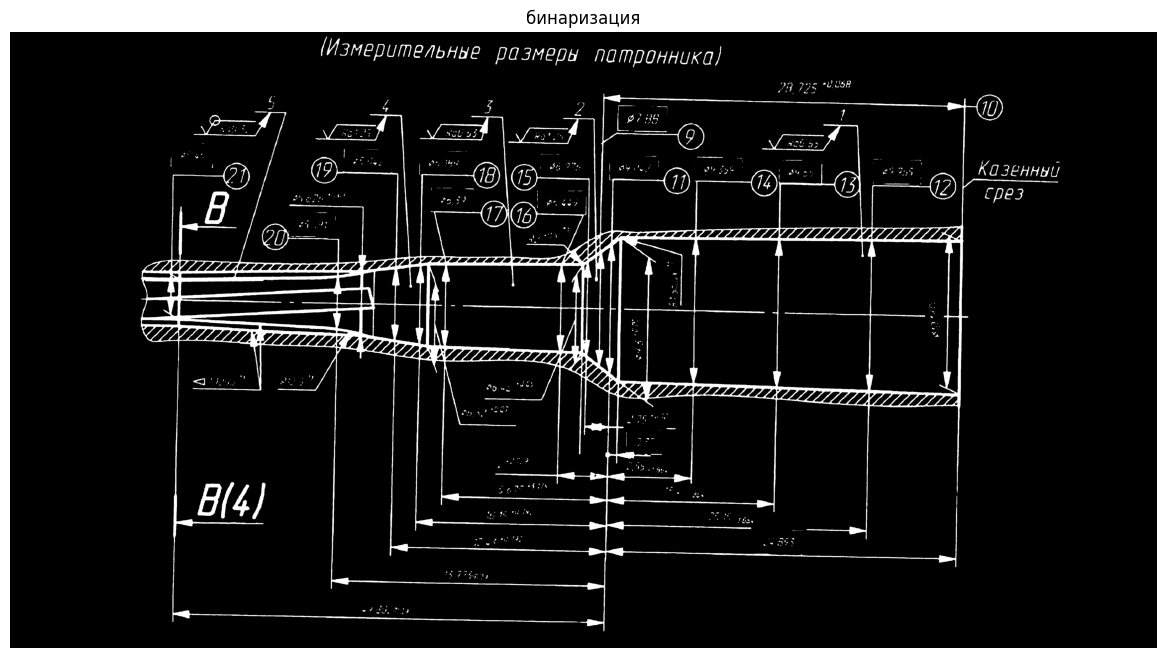

In [128]:
gray = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2GRAY)
blurred = cv2.GaussianBlur(gray, (5, 5), 0)
binary = cv2.threshold(blurred, 127, 255, cv2.THRESH_BINARY_INV)[1]
fg = binary > 0

n_cc = cv2.connectedComponents(binary, connectivity=8)[0] - 1
print(f"shape: {binary.shape} | dtype: {binary.dtype}")
print(f"передний план: {int(fg.sum())} px ({fg.mean() * 100:.2f}%) | связных компонент: {n_cc}")

plt.figure(figsize=(16, 8))
plt.imshow(binary, cmap="gray")
plt.axis("off")
plt.title("бинаризация")
plt.show()

## 3. Толщина штриха

`distanceTransform` даёт расстояние до ближайшего фонового пикселя, то есть половину локальной
ширины. Снимать значения нужно **только с медиальной оси**: на краях штриха оценка занижена по
построению и смазывает гистограмму.

Множитель в формуле подбирать не надо — он лишь меняет шкалу. Классы определяются кластеризацией,
а она инвариантна к монотонному преобразованию: `2d`, `2d-1` и `3d-1` дают одно и то же разбиение.

пикселей скелета: 130555 | компрессия площадь/скелет: 9.20
толщина на оси, px — min/median/max: 2.00 / 11.00 / 80.00
перцентили (10/25/50/75/90/99): [np.float64(8.0), np.float64(8.0), np.float64(11.0), np.float64(17.0), np.float64(26.0), np.float64(53.0)]


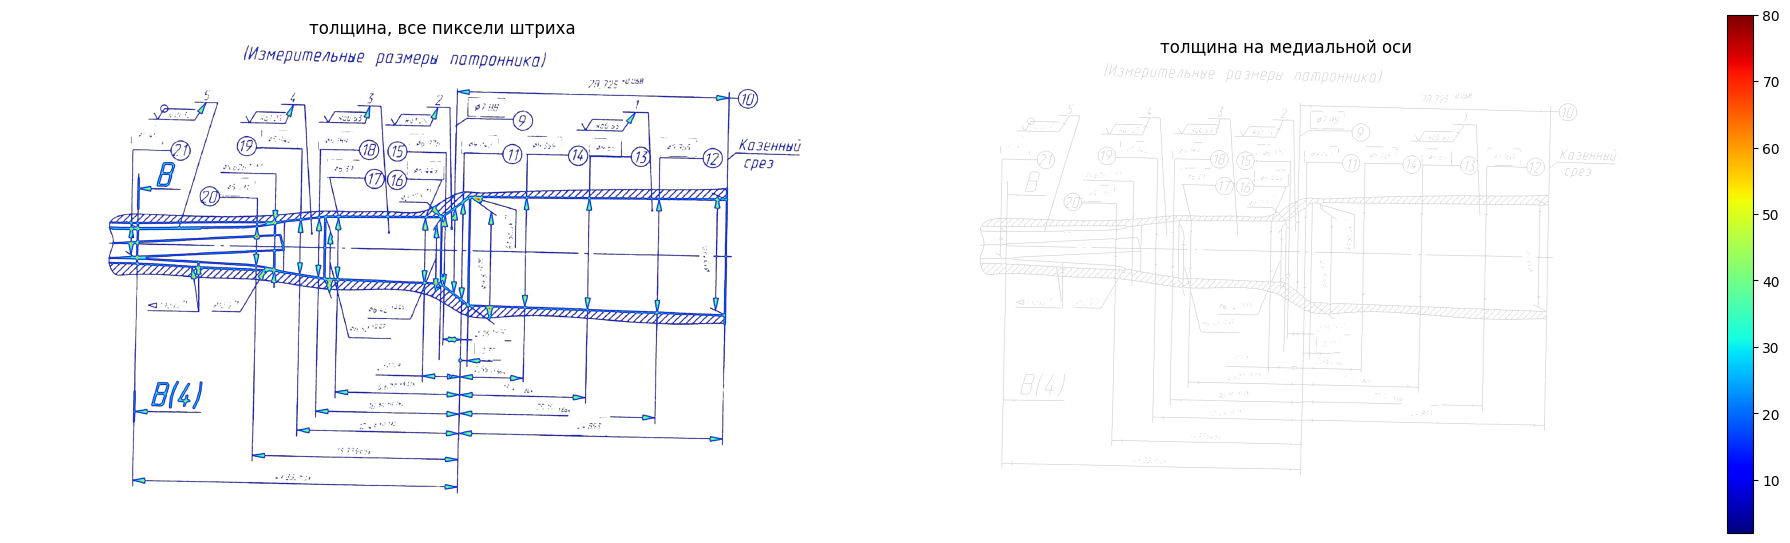

In [129]:
from skimage.morphology import skeletonize

skel = skeletonize(fg)
dist = cv2.distanceTransform(binary, cv2.DIST_L1, cv2.DIST_MASK_PRECISE)
thickness_map = 3 * dist - 1  # ширина штриха в px
t_axis = thickness_map[skel]  # только медиальная ось

print(f"пикселей скелета: {int(skel.sum())} | компрессия площадь/скелет: {fg.sum() / max(int(skel.sum()), 1):.2f}")
print(f"толщина на оси, px — min/median/max: {t_axis.min():.2f} / {np.median(t_axis):.2f} / {t_axis.max():.2f}")
print("перцентили (10/25/50/75/90/99):", [round(v, 2) for v in np.percentile(t_axis, [10, 25, 50, 75, 90, 99])])

fig, ax = plt.subplots(1, 2, figsize=(18, 6))
ax[0].imshow(np.where(fg, thickness_map, np.nan), cmap="jet")
ax[0].set_title("толщина, все пиксели штриха")
ax[0].axis("off")
im = ax[1].imshow(np.where(skel, thickness_map, np.nan), cmap="jet")
ax[1].set_title("толщина на медиальной оси")
ax[1].axis("off")
plt.colorbar(im, ax=ax[1], fraction=0.03)
plt.tight_layout()
plt.show()

## 4. Классы толщины

Число классов выбирается по silhouette и излому inertia, а не назначается. На одномерных данных
KMeans и Otsu эквивалентны: первый минимизирует внутриклассовую дисперсию, второй максимизирует
межклассовую, а их сумма постоянна.

In [130]:
from ipywidgets import IntSlider, interact
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

X = t_axis.reshape(-1, 1).astype(np.float64)
rng = np.random.default_rng(0)
idx = rng.choice(len(X), size=min(5000, len(X)), replace=False)  # silhouette квадратичен

models = {}
print(f"{'k':>2} | {'inertia':>14} | {'silhouette':>10} | центры, px")
for kk in range(2, 7):
    models[kk] = KMeans(n_clusters=kk, n_init=10, random_state=0).fit(X)
    sil = silhouette_score(X[idx], models[kk].predict(X[idx]))
    print(
        f"{kk:2d} | {models[kk].inertia_:14.1f} | {sil:10.3f} | {np.sort(models[kk].cluster_centers_.ravel()).round(2)}"
    )


@interact(k=IntSlider(value=3, min=2, max=6, step=1, continuous_update=False, description="классов"))
def preview_k(k):
    centers = np.sort(models[k].cluster_centers_.ravel())
    bounds = (centers[:-1] + centers[1:]) / 2
    cls_axis = np.digitize(t_axis, bounds)
    base = float(np.median(t_axis[cls_axis == 0]))

    print("границы, px:", bounds.round(2))
    for i in range(k):
        m = cls_axis == i
        med = float(np.median(t_axis[m])) if m.any() else float("nan")
        print(
            f"класс {i}: центр {centers[i]:5.2f} | доля {m.mean() * 100:5.1f}% | "
            f"медиана {med:5.2f} px | x{med / base:.2f} к самому тонкому"
        )

    cls_preview = np.digitize(thickness_map, bounds)
    vis = np.zeros((*binary.shape, 3), dtype=np.uint8)
    for i in range(k):
        vis[fg & (cls_preview == i)] = PALETTE[i]

    fig, ax = plt.subplots(2, 1, figsize=(18, 13), height_ratios=[1, 3])
    ax[0].hist(t_axis, bins=60, color="gray")
    for b in bounds:
        ax[0].axvline(b, color="red", ls="--")
    for i, c in enumerate(centers):
        ax[0].axvline(c, color=np.array(PALETTE[i]) / 255, lw=2)
    ax[0].grid(alpha=0.3)
    ax[0].set_xlabel("толщина, px")
    ax[1].imshow(vis)
    ax[1].axis("off")
    ax[1].set_title(f"k={k}: " + ", ".join(f"класс {i} = {centers[i]:.1f}px" for i in range(k)))
    plt.tight_layout()
    plt.show()

 k |        inertia | silhouette | центры, px
 2 |      3889066.7 |      0.742 | [10.29 31.19]
 3 |      1720281.8 |      0.743 | [ 9.89 25.55 47.5 ]
 4 |      1099094.8 |      0.690 | [ 7.33 12.31 25.55 47.5 ]
 5 |       685437.9 |      0.695 | [ 7.33 12.31 24.12 36.27 53.52]
 6 |       533001.4 |      0.768 | [ 7.33 11.   14.56 24.12 36.27 53.52]


interactive(children=(IntSlider(value=3, continuous_update=False, description='классов', max=6, min=2), Output…

Фиксируем `k = 3`: класс 0 — тонкие линии (размерные, выносные, осевые, штриховка),
класс 1 — основной штрих, класс 2 — заливки.

Важно: класс — это только «толще среднего по чертежу». Он **не** равен «наконечник»: на части
файлов стрелки попадают в класс 1 вместе с контуром, а утолщения контура — в класс 2.

класс 0: центр  9.89 px | пикселей   984394 ( 81.9%)
класс 1: центр 25.55 px | пикселей   177076 ( 14.7%)
класс 2: центр 47.50 px | пикселей    39942 (  3.3%)


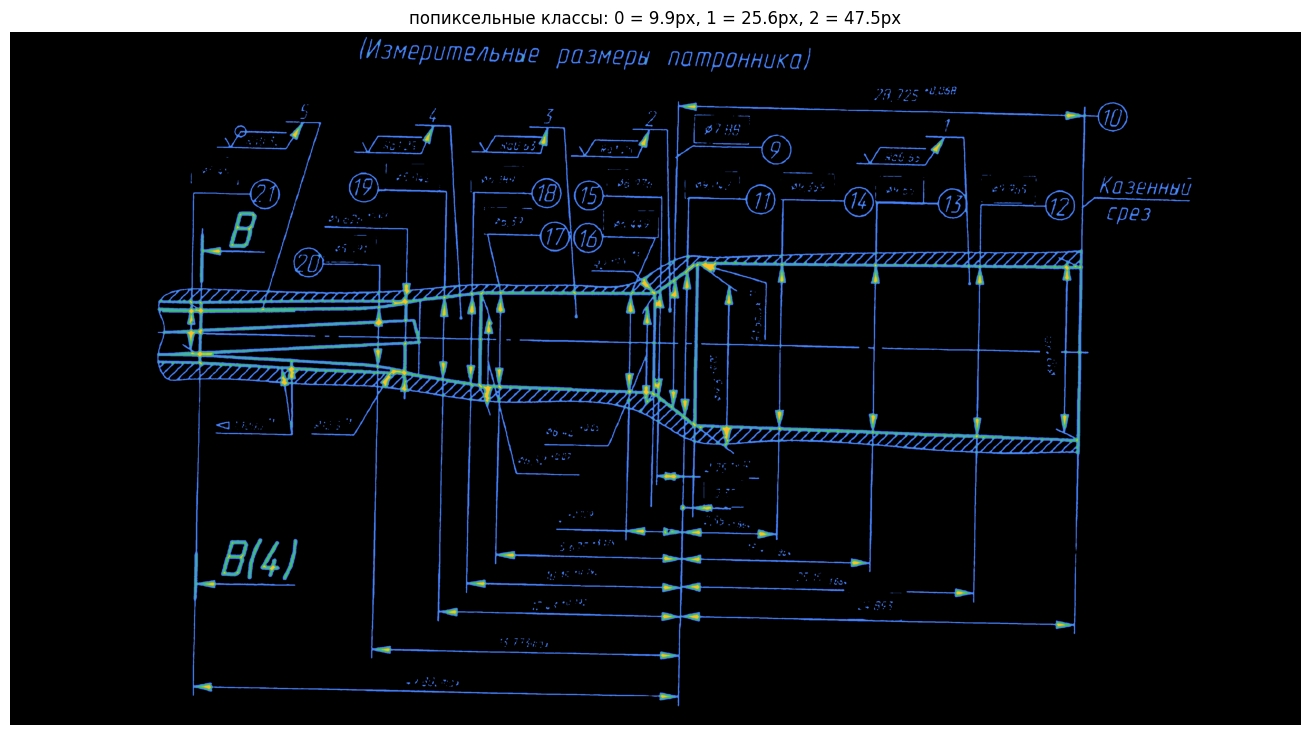

In [131]:
k = 3
centers = np.sort(models[k].cluster_centers_.ravel())
bounds = (centers[:-1] + centers[1:]) / 2
cls_img = np.digitize(thickness_map, bounds)  # попиксельный класс толщины

for i in range(k):
    m = fg & (cls_img == i)
    print(f"класс {i}: центр {centers[i]:5.2f} px | пикселей {int(m.sum()):8d} ({m.sum() / fg.sum() * 100:5.1f}%)")

vis = np.zeros((*binary.shape, 3), dtype=np.uint8)
for i in range(k):
    vis[fg & (cls_img == i)] = PALETTE[i]

plt.figure(figsize=(18, 9))
plt.imshow(vis)
plt.axis("off")
plt.title("попиксельные классы: " + ", ".join(f"{i} = {centers[i]:.1f}px" for i in range(k)))
plt.show()

## 5. Класс ребра по большинству голосов

Попиксельная классификация упирается в потолок: в узлах пересечений и на пологих дугах в штрих
вписывается круг большего радиуса, и одна линия красится в разные классы. Граф `skan` режет
скелет на рёбра — участки между узлами ветвления, — и класс назначается ребру целиком по моде
попиксельных классов. Скелету на вход подаются значения толщины, поэтому `mean_pixel_value`
в таблице рёбер это средняя толщина ребра.

In [132]:
from skan import Skeleton, summarize

sk_val = np.where(skel, thickness_map, 0).astype(np.float32)
assert sk_val[skel].min() > 0, "на скелете есть нули — skan срежет эти пиксели"

graph = Skeleton(sk_val)
br = summarize(graph, separator="_")
coords = graph.coordinates.astype(int)

# id ребра для каждого пикселя скелета
edge_of_sk = np.full(skel.shape, -1, dtype=np.int32)
for i in range(graph.n_paths):
    c = graph.path_coordinates(i).astype(int)
    edge_of_sk[c[:, 0], c[:, 1]] = i

TYPES = {0: "конец-конец", 1: "узел-конец", 2: "узел-узел", 3: "цикл"}
br["type_name"] = br["branch_type"].map(TYPES)
n_nodes = pd.unique(br[["node_id_src", "node_id_dst"]].to_numpy().ravel()).size

print(f"рёбер: {graph.n_paths} | узлов: {n_nodes} | подграфов: {br['skeleton_id'].nunique()}")
print(
    br.groupby("type_name")
    .agg(
        n=("branch_distance", "size"),
        len_med=("branch_distance", "median"),
        len_max=("branch_distance", "max"),
        thick_med=("mean_pixel_value", "median"),
    )
    .round(2)
    .to_string()
)

рёбер: 2529 | узлов: 2948 | подграфов: 808
                n  len_med  len_max  thick_med
type_name                                     
конец-конец   699     6.24   209.10       5.00
узел-конец    504    16.90   721.77      10.37
узел-узел    1299    47.07  2232.78      18.00
цикл           27   190.81   466.76      10.33


чистота голосования, медиана: 1.000 | смешанных рёбер (purity < 0.9): 685
пикселей сменили класс: 343676 (28.61%)
класс 0: рёбер  1832 | пикселей было   984394 -> стало   753092
класс 1: рёбер   424 | пикселей было   177076 -> стало   345581
класс 2: рёбер   273 | пикселей было    39942 -> стало   102542


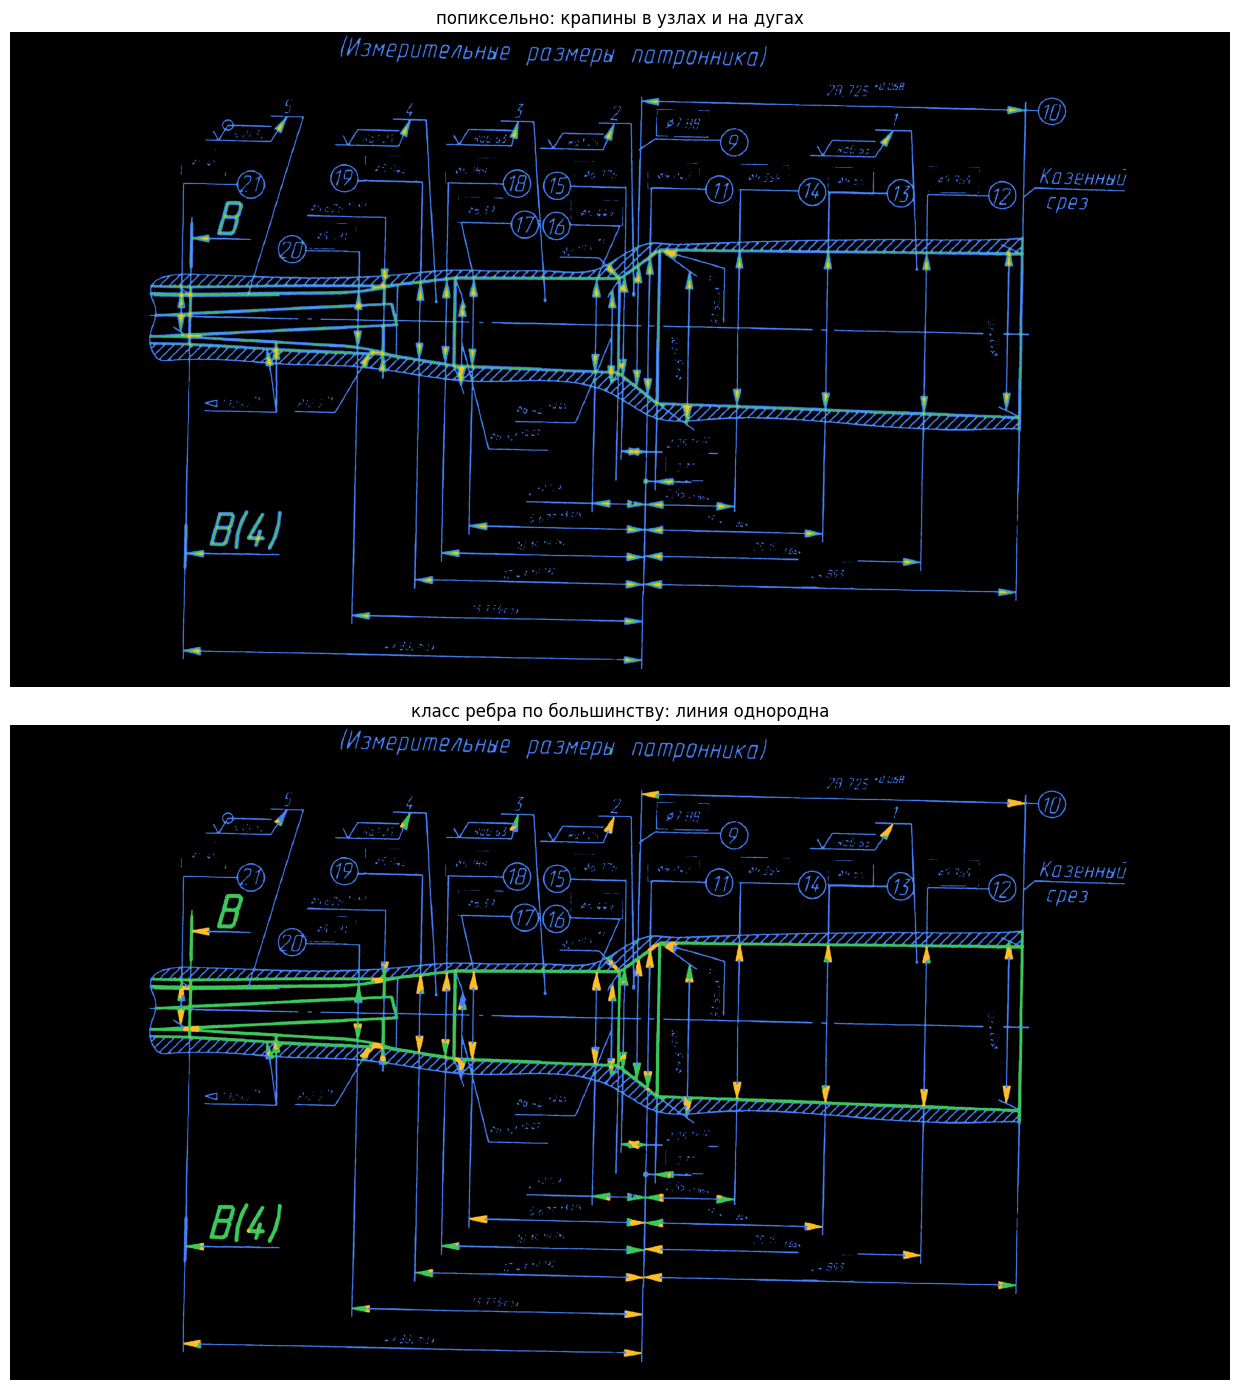

In [133]:
P = graph.paths[:, : coords.shape[0]].copy()
P.data[:] = 1  # индикатор «пиксель принадлежит ребру»

px_cls = cls_img[coords[:, 0], coords[:, 1]]
votes = np.column_stack([P @ (px_cls == c).astype(np.float32) for c in range(k)])
edge_cls = votes.argmax(1)
purity = votes.max(1) / votes.sum(1).clip(min=1)

# каждый пиксель приписан к ближайшему пикселю скелета, а значит к ребру
_, lbl = cv2.distanceTransformWithLabels(
    (~skel).astype(np.uint8), cv2.DIST_L2, cv2.DIST_MASK_PRECISE, labelType=cv2.DIST_LABEL_PIXEL
)
lut = np.full(int(lbl.max()) + 1, -1, dtype=np.int32)
lut[lbl[skel]] = edge_of_sk[skel]
edge_img = lut[lbl]
cls_vote = np.where(edge_img >= 0, edge_cls[np.clip(edge_img, 0, None)], -1)

print(
    f"чистота голосования, медиана: {np.median(purity):.3f} | "
    f"смешанных рёбер (purity < 0.9): {int((purity < 0.9).sum())}"
)
print(f"пикселей сменили класс: {int((cls_vote != cls_img)[fg].sum())} ({(cls_vote != cls_img)[fg].mean() * 100:.2f}%)")
for c in range(k):
    print(
        f"класс {c}: рёбер {int((edge_cls == c).sum()):5d} | "
        f"пикселей было {int((cls_img[fg] == c).sum()):8d} -> стало {int((cls_vote[fg] == c).sum()):8d}"
    )

vis_old = np.zeros((*binary.shape, 3), dtype=np.uint8)
vis_new = np.zeros((*binary.shape, 3), dtype=np.uint8)
for c in range(k):
    vis_old[fg & (cls_img == c)] = PALETTE[c]
    vis_new[fg & (cls_vote == c)] = PALETTE[c]

fig, ax = plt.subplots(2, 1, figsize=(18, 14))
ax[0].imshow(vis_old)
ax[0].set_title("попиксельно: крапины в узлах и на дугах")
ax[0].axis("off")
ax[1].imshow(vis_new)
ax[1].set_title("класс ребра по большинству: линия однородна")
ax[1].axis("off")
plt.tight_layout()
plt.show()

## 6. Удаление тонких линий

Удалять по разбиению Вороного нельзя: в месте, где тонкая линия упирается в толстую, часть тела
толстой оказывается ближе к чужому скелету, и в контуре выедается выемка.

Правильный способ — восстановить оставляемые штрихи из их же оси: штрих есть объединение
максимальных вписанных кругов с центрами на медиальной оси. Пиксель остаётся, если попадает
в круг ближайшей **оставляемой** точки оси.

пикселей: 1201412 -> 492553 (41.0%)
спасено от выедания: 54515 px (12.17% к наивному варианту)


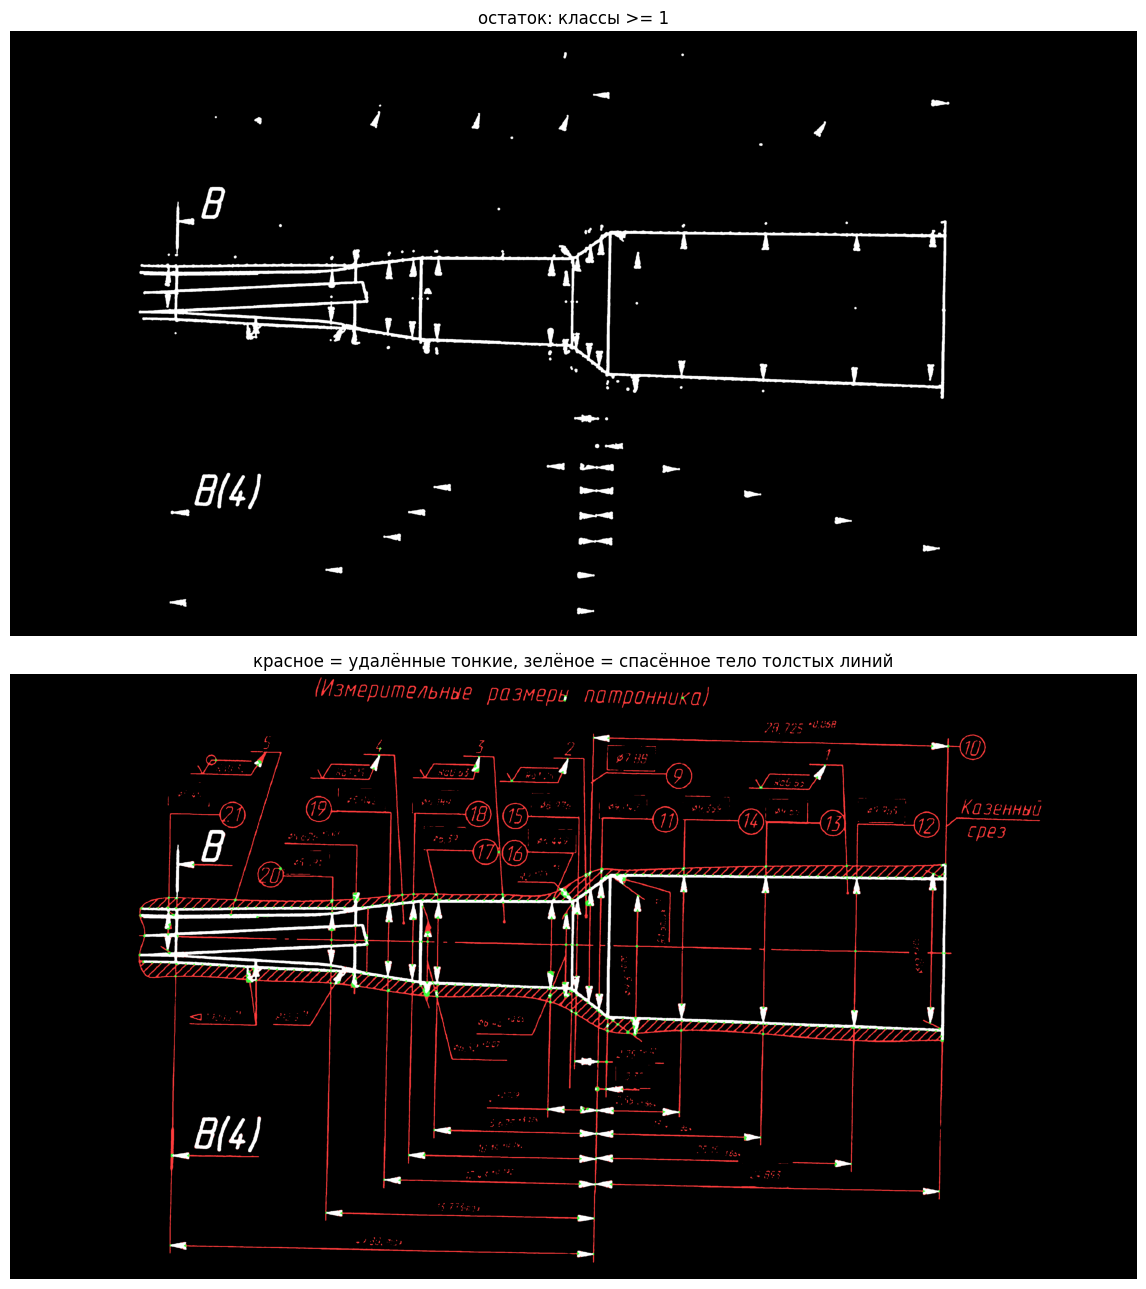

In [134]:
KEEP_FROM = 1  # выбрасываем класс 0

dist_l2 = cv2.distanceTransform(binary, cv2.DIST_L2, cv2.DIST_MASK_PRECISE)  # радиус вписанного круга
keep_edge = edge_cls >= KEEP_FROM
sk_keep = skel & (edge_of_sk >= 0) & keep_edge[np.clip(edge_of_sk, 0, None)]

D, lbl_k = cv2.distanceTransformWithLabels(
    (~sk_keep).astype(np.uint8), cv2.DIST_L2, cv2.DIST_MASK_PRECISE, labelType=cv2.DIST_LABEL_PIXEL
)
rad = np.zeros(int(lbl_k.max()) + 1, dtype=np.float32)
rad[lbl_k[sk_keep]] = dist_l2[sk_keep]

mask_thick = fg & (D <= rad[lbl_k] + 0.5)
naive = fg & (edge_img >= 0) & keep_edge[np.clip(edge_img, 0, None)]  # для сравнения: по Вороному
rescued = mask_thick & ~naive

print(f"пикселей: {int(fg.sum())} -> {int(mask_thick.sum())} ({mask_thick.sum() / fg.sum() * 100:.1f}%)")
print(
    f"спасено от выедания: {int(rescued.sum())} px "
    f"({rescued.sum() / max(int(naive.sum()), 1) * 100:.2f}% к наивному варианту)"
)

vis = np.zeros((*binary.shape, 3), dtype=np.uint8)
vis[mask_thick] = (255, 255, 255)
vis[fg & ~mask_thick] = (255, 60, 60)
vis[rescued] = (60, 255, 60)

fig, ax = plt.subplots(2, 1, figsize=(18, 13))
ax[0].imshow(mask_thick, cmap="gray")
ax[0].set_title(f"остаток: классы >= {KEEP_FROM}")
ax[0].axis("off")
ax[1].imshow(vis)
ax[1].set_title("красное = удалённые тонкие, зелёное = спасённое тело толстых линий")
ax[1].axis("off")
plt.tight_layout()
plt.show()

## 7. Наконечники как пики ширины

Что уже перепробовано и почему не работает: связная компонента сливает наконечник с контуром;
path opening его сохраняет, потому что через него проходит длинный путь вдоль линии; прунинг
висячих веток режет вместе с ним законные концы линий; кластеризация дескрипторов формы
проваливается там, где стрелок мало.

Работает другое. Ширина штриха вдоль чертежа кусочно-постоянна, и наконечник — единственное
место, где она вырастает и падает обратно. Мера — выпуклость пика над окружением:

| структура | выпуклость над плато |
|---|---|
| пересечение двух линий ширины `w` | `≈ 0.2 w` (вписанный круг в перекрестье, `w/√2`) |
| изгиб, стык | десятые доли `w` |
| **наконечник** | `(W − w)/2 ≈ 1…2 w`, так как `W/w` порядка 3–4 |
| конец линии | пика нет вообще: к торцу distance transform убывает |

Между мусором и наконечником зазор почти в порядок, поэтому порог `h` имеет широкое безопасное
окно. Ровно это и делает `h_maxima`. Концы линий не могут быть задеты по построению — именно та
проблема, из-за которой не годился прунинг.

пикселей маски: 492553 | скелета: 27813
ширина штриха: медиана 17.1 px | на хребте distance transform 8.5


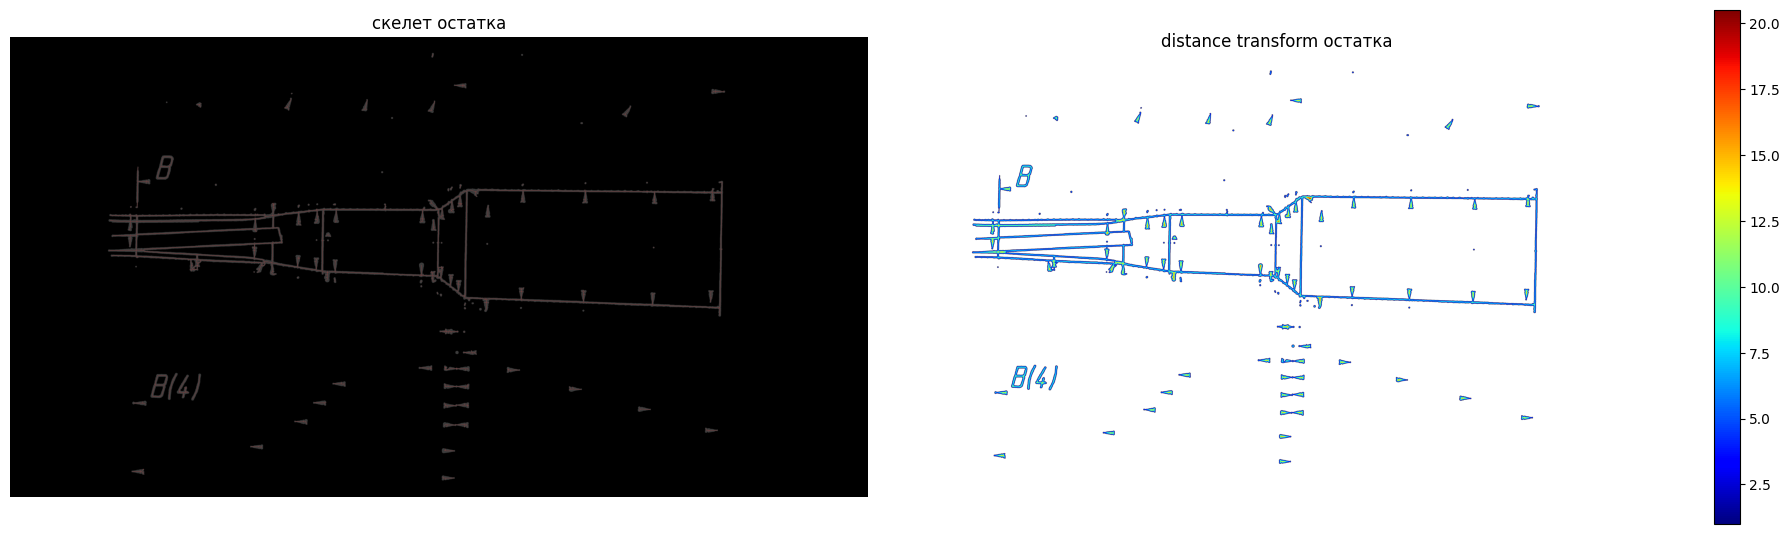

In [135]:
mask_thick_u8 = np.where(mask_thick, 255, 0).astype(np.uint8)
skel_t = skeletonize(mask_thick)
dist_t = cv2.distanceTransform(mask_thick_u8, cv2.DIST_L2, cv2.DIST_MASK_PRECISE)
w_med = float(np.median(dist_t[skel_t]) * 2)  # медианная ширина штриха в остатке

print(f"пикселей маски: {int(mask_thick.sum())} | скелета: {int(skel_t.sum())}")
print(f"ширина штриха: медиана {w_med:.1f} px | на хребте distance transform {w_med / 2:.1f}")

vis = np.zeros((*mask_thick.shape, 3), dtype=np.uint8)
vis[mask_thick] = (60, 60, 60)
vis[skel_t] = (255, 80, 80)

fig, ax = plt.subplots(1, 2, figsize=(18, 6))
ax[0].imshow(vis)
ax[0].set_title("скелет остатка")
ax[0].axis("off")
im = ax[1].imshow(np.where(mask_thick, dist_t, np.nan), cmap="jet")
ax[1].set_title("distance transform остатка")
ax[1].axis("off")
plt.colorbar(im, ax=ax[1], fraction=0.03)
plt.tight_layout()
plt.show()

Три параметра. `h` — выпуклость пика (в долях ширины штриха), отсекает стыки и перекрестья.
`мин ширина пика` — отношение ширины в пике к ширине штриха, добивает остатки мусора.
`мин площадь семени` — снимает точечные пики от зерна.

Синие крестики показывают отвергнутое: по ним и настраивается порог.

In [136]:
from ipywidgets import FloatSlider, IntSlider, interact
from scipy import ndimage as ndi
from skimage.morphology import h_maxima

_seed_cache = {}


def seeds_for(h_mult):
    """h_maxima кешируется: два других ползунка не должны его пересчитывать."""
    if h_mult not in _seed_cache:
        s = h_maxima(dist_t, h_mult * w_med / 2).astype(np.uint8)
        n, lab_s, st_s, cen = cv2.connectedComponentsWithStats(s, connectivity=8)
        rmax = np.array(ndi.maximum(dist_t, lab_s, index=np.arange(1, n))) if n > 1 else np.zeros(0)
        _seed_cache[h_mult] = (n, st_s, cen, rmax)
    return _seed_cache[h_mult]


@interact(
    h_mult=FloatSlider(value=0.8, min=0.2, max=4.0, step=0.1, continuous_update=False, description="h / ширина"),
    min_ratio=FloatSlider(
        value=1.9, min=1.0, max=4.0, step=0.05, continuous_update=False, description="мин ширина пика"
    ),
    min_area=IntSlider(value=1, min=1, max=200, step=1, continuous_update=False, description="мин площадь"),
)
def find_tips(h_mult, min_ratio, min_area):
    n, st_s, cen, rmax = seeds_for(h_mult)
    if n <= 1:
        print("ни одного пика")
        return

    ratio = 2 * rmax / w_med
    area = st_s[1:, cv2.CC_STAT_AREA]
    ok = (ratio >= min_ratio) & (area >= min_area)

    print(f"h = {h_mult * w_med / 2:.1f} px (в радиусах) | пиков: {n - 1} -> принято: {int(ok.sum())}")
    if ok.any():
        print(
            f"принятые: ширина/штрих медиана {np.median(ratio[ok]):.2f}, "
            f"площадь семени медиана {np.median(area[ok]):.0f}"
        )

    vis = cv2.cvtColor(np.where(mask_thick, 70, 0).astype(np.uint8), cv2.COLOR_GRAY2BGR)
    for (cx, cy), r, good in zip(cen[1:], rmax, ok):
        c = (int(cx), int(cy))
        if good:
            cv2.circle(vis, c, max(int(r), 3), (255, 150, 40), 2)
        else:
            cv2.drawMarker(vis, c, (80, 140, 255), cv2.MARKER_TILTED_CROSS, 14, 1)

    fig, ax = plt.subplots(2, 1, figsize=(18, 13), height_ratios=[1, 4])
    ax[0].hist(ratio[ok], bins=40, color="orange", label="принято")
    ax[0].hist(ratio[~ok], bins=40, color="gray", alpha=0.7, label="отсеяно")
    ax[0].axvline(min_ratio, color="red", ls="--")
    ax[0].set_xlabel("ширина пика / ширина штриха")
    ax[0].legend()
    ax[0].grid(alpha=0.3)
    ax[1].imshow(vis)
    ax[1].axis("off")
    ax[1].set_title(f"h={h_mult}x, ширина>={min_ratio}, площадь>={min_area}: {int(ok.sum())} наконечников")
    plt.tight_layout()
    plt.show()

interactive(children=(FloatSlider(value=0.8, continuous_update=False, description='h / ширина', max=4.0, min=0…

наконечников удалено: 45 | ядер задето: 42
пикселей: 492553 -> 455561 (снято 36992, 7.51%)
компонент: 81 -> 99 | замкнутых контуров: 24 -> 17


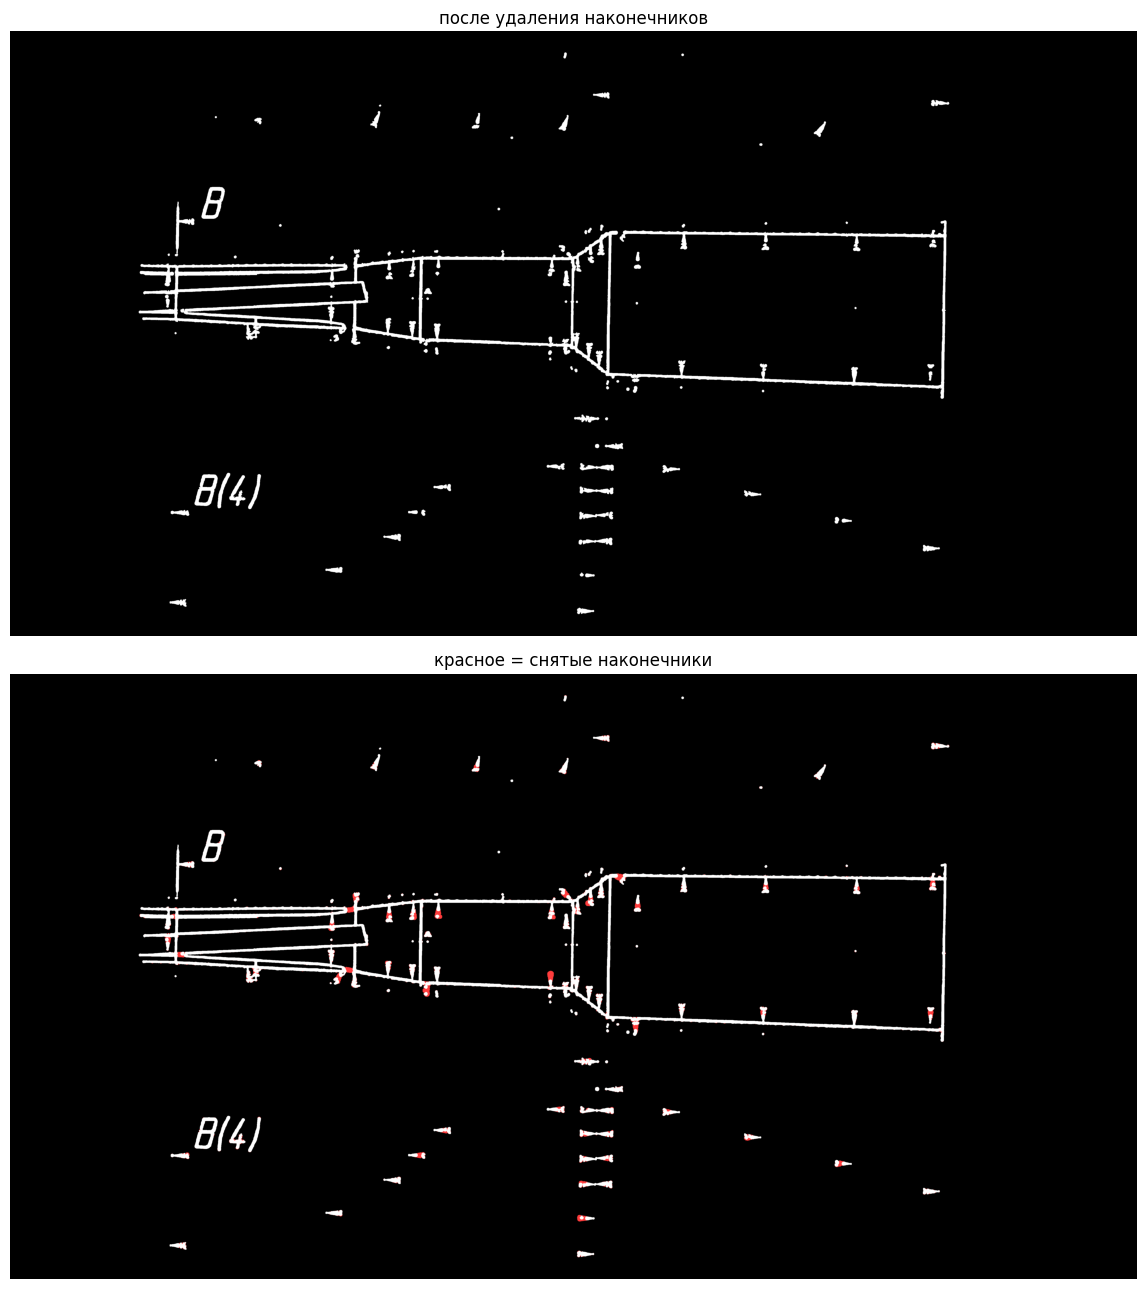

In [168]:
from skimage.morphology import h_maxima

H_MULT, MIN_RATIO, MIN_AREA = 0.8, 1.8, 1
CORE_LEVEL = 1.3  # ядро наконечника: где ширина выше линейной в N раз

# принятые семена
seeds = h_maxima(dist_t, H_MULT * w_med / 2).astype(np.uint8)
n_s, lab_s, st_s, cen = cv2.connectedComponentsWithStats(seeds, connectivity=8)
rmax = np.array(ndi.maximum(dist_t, lab_s, index=np.arange(1, n_s)))
ok = (2 * rmax / w_med >= MIN_RATIO) & (st_s[1:, cv2.CC_STAT_AREA] >= MIN_AREA)
seed_ok = np.zeros(n_s, dtype=bool)
seed_ok[1:] = ok
seed_px = seed_ok[lab_s]

# ядро = связная область, где штрих заметно шире линии; берём только те, где есть семя
core = dist_t >= CORE_LEVEL * w_med / 2
n_c, lab_c = cv2.connectedComponents(core.astype(np.uint8), connectivity=8)
hit = np.unique(lab_c[seed_px & core])
core_ok = np.zeros(n_c, dtype=bool)
core_ok[hit[hit > 0]] = True
tip_core = core_ok[lab_c]

# удаляем ось наконечников, остальное восстанавливаем по кругам
sk_keep2 = skel_t & ~tip_core
D2, lb2 = cv2.distanceTransformWithLabels(
    (~sk_keep2).astype(np.uint8), cv2.DIST_L2, cv2.DIST_MASK_PRECISE, labelType=cv2.DIST_LABEL_PIXEL
)
rad2 = np.zeros(int(lb2.max()) + 1, dtype=np.float32)
rad2[lb2[sk_keep2]] = dist_t[sk_keep2]
mask_clean = mask_thick & (D2 <= rad2[lb2] + 0.5)
removed = mask_thick & ~mask_clean


def holes(m, min_area=20):
    cnts, hier = cv2.findContours(np.where(m, 255, 0).astype(np.uint8), cv2.RETR_CCOMP, cv2.CHAIN_APPROX_SIMPLE)
    return 0 if hier is None else sum(1 for c, h in zip(cnts, hier[0]) if h[3] >= 0 and cv2.contourArea(c) >= min_area)


cc_before = cv2.connectedComponents(np.where(mask_thick, 255, 0).astype(np.uint8), connectivity=8)[0] - 1
cc_after = cv2.connectedComponents(np.where(mask_clean, 255, 0).astype(np.uint8), connectivity=8)[0] - 1
print(f"наконечников удалено: {int(seed_ok.sum())} | ядер задето: {len(hit[hit > 0])}")
print(
    f"пикселей: {int(mask_thick.sum())} -> {int(mask_clean.sum())} "
    f"(снято {int(removed.sum())}, {removed.sum() / mask_thick.sum() * 100:.2f}%)"
)
print(f"компонент: {cc_before} -> {cc_after} | замкнутых контуров: {holes(mask_thick)} -> {holes(mask_clean)}")

vis = np.zeros((*mask_thick.shape, 3), dtype=np.uint8)
vis[mask_clean] = (255, 255, 255)
vis[removed] = (255, 60, 60)

fig, ax = plt.subplots(2, 1, figsize=(18, 13))
ax[0].imshow(mask_clean, cmap="gray")
ax[0].set_title("после удаления наконечников")
ax[0].axis("off")
ax[1].imshow(vis)
ax[1].set_title("красное = снятые наконечники")
ax[1].axis("off")
plt.tight_layout()
plt.show()


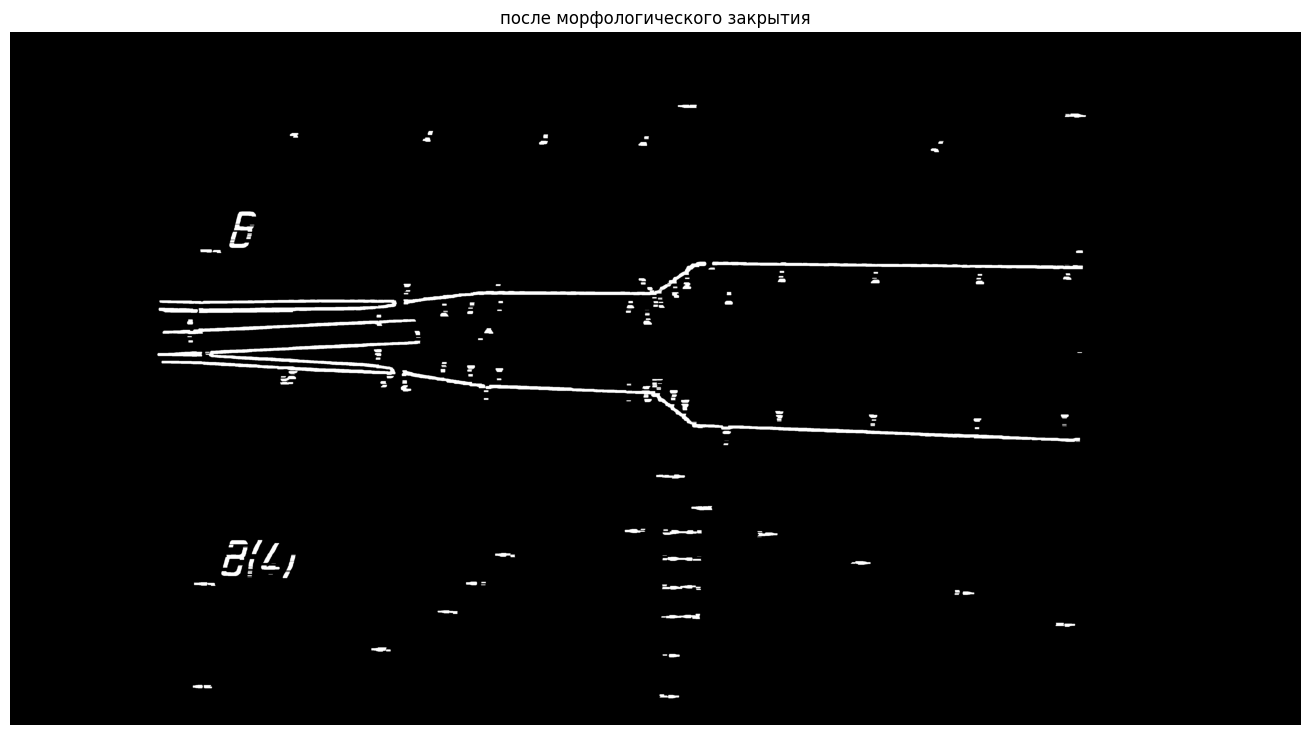

In [ ]:
v_kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (21, 1))
v_mask = cv2.morphologyEx(mask_clean.astype(np.uint8), cv2.MORPH_OPEN, v_kernel, iterations=1)

plt.figure(figsize=(18, 9))
plt.imshow(v_mask, cmap="gray")
plt.axis("off")
plt.title("после морфологического закрытия")
plt.show()


## Что дальше

1. **Удаление найденных наконечников.** Семена есть, снимать надо область вокруг семени, где
   ширина держится выше линейной, и обязательно с восстановлением по кругам — как в шаге 6,
   иначе выест контур.
2. **Буквы.** Жирный штрих текста даёт такие же пики ширины. Толщиной они не отделяются;
   снимаются отдельным детектором текста, здесь не разбираются.
3. **Реальные утолщения детали** (бобышки, залитые участки) проходят фильтр законно. Отличить
   их от наконечника можно тем, что наконечник сидит у свободного конца штриха, а утолщение
   детали — внутри контура.
4. **Перенос на весь датасет.** Датасет распадается на два мира: рендеры около 86 dpi и сканы
   6800–9200 px. Абсолютные пороги между ними не переносятся, поэтому все признаки здесь
   нормированы на медианную ширину штриха самого изображения.